In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime
from scipy.stats import pearsonr

In [14]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import cartopy.io.shapereader as shpreader
import matplotlib.colors as colors
from scipy.stats import pearsonr

In [15]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

In [16]:
import numpy as np
from scipy.stats import gaussian_kde
from multiprocessing import Pool
import time

In [18]:
#read daate
#dayall  = ['01','02','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24','25','26','27','28','29','30','31']
year = ['2015','2016','2017','2018','2019',]
#year = ['2015',]

#mon  = ['01']
mon  = ['01','02','03','04','05','06','07','08','09','10','11','12']
#year = ['2016',]
dayall  = ['01','02','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24','25','26','27','28','29','30','31']

#dayall  = ['01']


ZZ_sum = np.zeros((360,180))
num = np.zeros((360,180))
#ZZ[ZZ==0.0] = None

xco2_obs_y = []
xco2_naq_y = []

for iyear in year:
    #colors=['red','blue','green','orange'] 
    colors=['green','red','orange','blue'] 


    for imon in mon:
        xco2_obs_m = []
        xco2_naq_m = []
        if ((imon=='01')or(imon=='03')or(imon=='05')or(imon=='07')or(imon=='08')or(imon=='10')or(imon=='12')):
            day = dayall[:]
        elif ((imon=='04')or(imon=='06')or(imon=='09')or(imon=='11')):
            day = dayall[:-1]
        elif (imon=='02'):
            day = dayall[:-3]
        

        for iday in day:
            filename_obs = f'D:/workdata/43_met_station_statistic/xco2/obs2015to2020/obs.{iyear}{imon}{iday}T+00.csv'
            df_obs = pd.read_csv(filename_obs)
            xco2_obs = df_obs['xco2']
            filename_naq = f'D:/论文撰写/NAQPMS-CO2多源模式验证/数据作图/卫星格点图/ct.g_data/sim.{iyear}{imon}{iday}T+00.zhouRunAll.csv'
            df_naq = pd.read_csv(filename_naq)
            xco2_naq = df_naq['xco2']

            xco2_obs_m.extend(list(xco2_obs.values))
            xco2_naq_m.extend(list(xco2_naq.values))

            xco2_obs_y.extend(list(xco2_obs.values))
            xco2_naq_y.extend(list(xco2_naq.values))



In [6]:
xy = np.vstack([xco2_naq_y, xco2_obs_y[3:]])
z = gaussian_kde(xy)(xy)

In [8]:
# Create a DataFrame
df = pd.DataFrame({'ct_year': z,})

# Save the DataFrame to a CSV file
df.to_csv(r'D:\论文撰写\NAQPMS多源模式验证与加拿大模拟\数据作图\gauss\ct.year.csv', index=False)

In [20]:
df_read = pd.read_csv(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\gauss\ct.year.csv')

In [21]:
z = df_read['ct_year']

In [22]:
xco2_obs_y = xco2_obs_y[3:]

C:\Users\zouzhiyin\AppData\Local\Temp\ipykernel_3108\644658301.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg=ax.legend(prop={'size':12},frameon=False,loc="upper left",\


['NP=1363140 ', 'MO=404.42 ppm', 'MM=404.65 ppm', 'MB=0.23 ppm', 'NMB=0.06 %', 'RMSE=1.33 ppm', 'R=0.95 ']


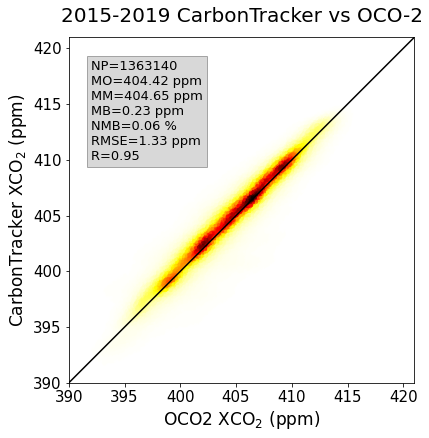

In [24]:

fig = plt.figure(figsize=(6,6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

#xy = np.vstack([xco2_naq_y, xco2_obs_y])
#z = gaussian_kde(xy)(xy)
ax.scatter( xco2_obs_y,xco2_naq_y, c=z, s=5, cmap='hot_r', alpha=0.7)

ax.set(xlim=(390, 421), xticks=np.arange(390, 421, 5),
ylim=(390, 421), yticks=np.arange(390, 421, 5))

leg=ax.legend(prop={'size':12},frameon=False,loc="upper left",\
    ncol=1,bbox_to_anchor=(0.4,0.95),borderaxespad = 0.,markerscale=5.,handletextpad=0.1,labelspacing=0.2,columnspacing=0.1) #图例

#y=x
x = [0, 500]
y = [0, 500]
plt.plot(x,y,color='black')

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.grid(False)    

#filtData = delete_missing(obs, mdl)
xco2_obs_y = np.array(xco2_obs_y)
xco2_naq_y = np.array(xco2_naq_y)

MO = np.mean(xco2_obs_y),
MM = np.mean(xco2_naq_y),
MB = np.mean(xco2_naq_y - xco2_obs_y),
NMB = np.sum((xco2_naq_y - xco2_obs_y)/(np.sum(xco2_obs_y)))*100,
RMSE = np.sqrt( np.mean( (xco2_naq_y - xco2_obs_y)**2 ) ),
R = pearsonr(xco2_naq_y , xco2_obs_y)[0],
num = len(xco2_naq_y)

indexdata = [[num],MO,MM,MB,NMB,RMSE,R]
string_ = ['NP','MO','MM','MB','NMB','RMSE','R']
unitsting = ['','ppm','ppm','ppm','%','ppm','']
indeStr = []
for index in range(len(indexdata)):
    indeStr.append('='.join([ string_[index], str(np.round(indexdata[index][0],2))+" "+unitsting[index]]))
    #indeStr.append('='.join([ string_[index], str(np.round(indexdata[index][0],2))+" "+unitsting[index]]))
print(indeStr)
txt = '\n'.join(indeStr)
ax.text(392, 410, txt, horizontalalignment='left',bbox=dict(facecolor='grey', alpha=0.3),fontsize =13)

ax.set_ylabel('CarbonTracker XCO$_2$ (ppm)',fontsize=17)
ax.set_xlabel('OCO2 XCO$_2$ (ppm)',fontsize=17)
ax.set_title('2015-2019 CarbonTracker vs OCO-2',loc='center',fontsize =20,pad = 15)  

plt.rcParams['savefig.dpi'] = 500
plt.savefig(r'D:\论文撰写\NAQPMS-CO2多源模式验证\数据作图\obs_ct_xco2_5yrtest.r8.png'.format(iyear),bbox_inches='tight')
